# Занятие 15. Разброс, аномалии и проверка гипотез

> **Цель занятия:** научиться находить **выбросы** двумя правилами (**IQR** и **Z-score**),
> читать **boxplot** и **violin plot** по их геометрии, а затем переходить от описания данных
> к **выводам**: формулировать нулевую и альтернативную гипотезы, понимать **p-value** и
> выбирать подходящий тест — **t-тест Стьюдента**, **критерий Манна–Уитни** или **χ²**.

**Что будет:**
1. **Природа выбросов** — откуда они берутся и почему их нельзя удалять не глядя;
2. **Два правила поиска** — межквартильный размах (**IQR**) и **Z-score**;
3. **Boxplot и Violin** — геометрия графиков: медиана, квартили, усы, точки-выбросы;
4. **Методология гипотез** — **H₀**, **H₁**, уровень значимости и **p-value** простыми словами;
5. **Три теста** — **t-тест** и **Манна–Уитни** для сравнения средних, **χ²** для долей.

На занятии 11 мы **описывали** данные: центр, разброс, форму. Сегодня делаем следующий шаг —
**принимаем решения** по данным. Все инструменты — `IQR`, `boxplot`, тесты — служат одной задаче:
отличить настоящий эффект от случайного колебания.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats   # статистические тесты живут здесь

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 20)
sns.set_theme(style='whitegrid')

## Данные для примеров — просмотры видеорекламы

Рекламное агентство крутило **видеоролик** и записывало, сколько секунд его посмотрел каждый
пользователь. Ролик существует в двух вариантах — **креатив `A`** и **креатив `B`**; какой
показать, решал случай. Всего **1600 показов**.

| Столбец | Что означает |
|---|---|
| `user_id` | идентификатор пользователя |
| `platform` | где увидели рекламу: `mobile`, `desktop`, `tv` |
| `creative` | вариант ролика: `A` или `B` |
| `region` | регион пользователя |
| `age_group` | возрастная группа |
| `watch_time` | **сколько секунд** смотрели ролик |
| `clicked` | кликнул ли по рекламе: `1` — да, `0` — нет |

Главный вопрос заказчика простой: **какой креатив лучше**. Ответ на него мы и будем добывать
весь урок.

In [2]:
df = pd.read_csv('data/ads.csv', sep=';')
print('Размер таблицы:', df.shape)
df.head()

Размер таблицы: (1600, 7)


,user_id,platform,creative,region,age_group,watch_time,clicked
0,1001,desktop,B,Регионы,18-24,24.9,0
1,1002,desktop,B,Регионы,35-44,3.2,0
2,1003,mobile,B,Регионы,25-34,28.1,1
3,1004,mobile,B,Регионы,25-34,43.8,0
4,1005,desktop,B,Регионы,35-44,14.8,0


In [3]:
df['watch_time'].describe().round(1)

count    1600.0
mean       24.8
std        60.1
min         2.1
25%         9.0
50%        13.4
75%        21.3
max       595.2
Name: watch_time, dtype: float64

**Вывод:** половина пользователей смотрит ролик меньше **13 секунд**, но максимум —
**595 секунд**, почти десять минут. Среднее (**~25 с**) почти вдвое больше медианы, а
стандартное отклонение (**~60 с**) больше самого среднего. Такой отрыв `max` от `75%` —
первый сигнал, что в данных есть **аномалии**.

---
## Часть 1. Природа выбросов

**Выброс** (*outlier*) — наблюдение, которое сильно отличается от остальных. Слово «сильно»
надо превратить в число — этим займёмся во второй части. Сначала важнее понять: **выброс
выбросу рознь**. Причин у него три, и от причины зависит, что с ним делать.

| Причина | Пример в наших данных | Что делать |
|---|---|---|
| **Ошибка** ввода или сбора | `watch_time = -5` секунд, дата рождения 1899 | исправить или удалить |
| **Технический артефакт** | бот «смотрит» ролик 10 минут в фоне | удалить: это не человек |
| **Настоящее редкое значение** | зритель на `tv` реально досмотрел до конца | **оставить**: это данные, а не мусор |

Третья строка — самая важная. Выброс не синоним ошибки. Если удалять всё непохожее, можно
выкинуть именно то, ради чего затевался анализ: крупных клиентов, мошеннические транзакции,
редкие отказы оборудования.

Посмотрим на десять самых длинных просмотров:

In [4]:
df.nlargest(10, 'watch_time')[['user_id', 'platform', 'creative', 'watch_time', 'clicked']]

,user_id,platform,creative,watch_time,clicked
1446,2447,mobile,A,595.2,0
1522,2523,mobile,A,586.3,0
729,1730,mobile,B,582.5,0
436,1437,desktop,B,572.8,0
260,1261,mobile,A,561.6,0
881,1882,tv,B,558.6,0
123,1124,desktop,B,522.7,0
462,1463,mobile,A,516.1,0
117,1118,desktop,B,515.9,0
456,1457,mobile,A,508.1,0


**Вопрос:** ролик длится меньше минуты. Что за пользователи набрали сотни секунд просмотра
и почему среди них почти нет кликов?

> **На практике:** прежде чем удалять аномалию, всегда спрашивайте «**почему** она такая?».
> В антифроде и в мониторинге оборудования выбросы — это не помеха анализу, а **сам предмет**
> анализа: их не удаляют, а ищут.

---
## Часть 2. Два правила поиска выбросов

Глазами по таблице выбросы не найдёшь — нужно **правило**, которое можно применить ко всему
столбцу. Правил два, и они смотрят на данные по-разному.

### 2.1. Правило межквартильного размаха (IQR)

С квартилями мы познакомились на занятии 11: **Q1** — четверть данных ниже него, **Q3** — три
четверти ниже него, а **IQR = Q3 − Q1** — разброс центральной половины данных.

Правило **1.5 · IQR** отступает от краёв «коробки» полтора её размаха в каждую сторону.
Всё, что вышло за эти границы, считается выбросом:

$$\text{нижняя граница} = Q_1 - 1.5 \cdot IQR \qquad\qquad \text{верхняя граница} = Q_3 + 1.5 \cdot IQR$$

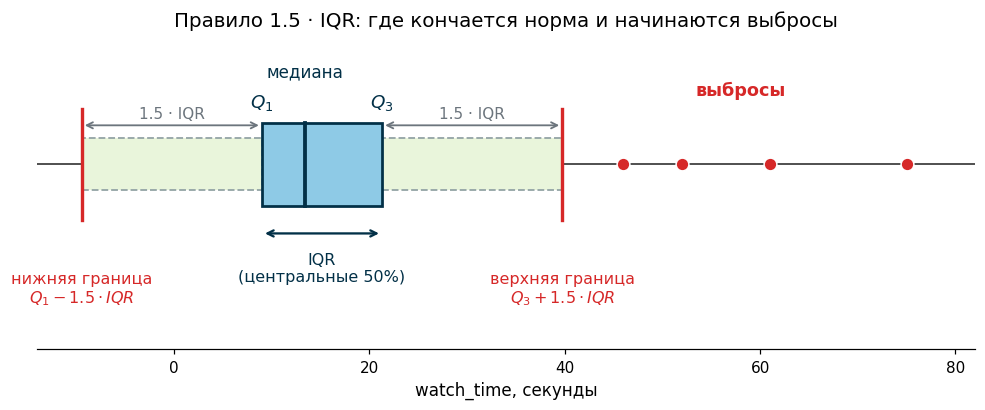

Ключевое свойство: `Q1`, `Q3` и медиана **не зависят** от того, насколько далеко улетели
крайние точки. Поэтому сами выбросы не сдвигают границы, по которым их ищут.

In [5]:
Q1 = df['watch_time'].quantile(0.25)
Q3 = df['watch_time'].quantile(0.75)
IQR = Q3 - Q1

low  = Q1 - 1.5 * IQR
high = Q3 + 1.5 * IQR

print('Q1 =', Q1, '| Q3 =', Q3, '| IQR =', round(IQR, 1))
print('границы нормы: от', round(low, 1), 'до', round(high, 1))

outliers_iqr = df[(df['watch_time'] < low) | (df['watch_time'] > high)]
print('выбросов по IQR:', len(outliers_iqr))

Q1 = 9.0 | Q3 = 21.3 | IQR = 12.3
границы нормы: от -9.5 до 39.8
выбросов по IQR: 118


**Вывод:** нормой считается просмотр примерно **до 40 секунд**; за границей оказались
**118** наблюдений. Нижняя граница получилась отрицательной — значит, снизу выбросов нет
физически: время просмотра не бывает меньше нуля.

### 2.2. Правило Z-score

**Z-score** отвечает на другой вопрос: **на сколько стандартных отклонений** значение отстоит
от среднего.

$$z_i = \frac{x_i - \bar{x}}{\sigma}$$

Значение с `z = 2` лежит на два стандартных отклонения выше среднего. Обычный порог —
**|z| > 3**: у нормального распределения за такими границами лежит меньше **0.3%** значений,
так что это действительно редкость.

In [6]:
z = (df['watch_time'] - df['watch_time'].mean()) / df['watch_time'].std()

outliers_z = df[z.abs() > 3]
print('выбросов по Z-score:', len(outliers_z))
print('минимальный watch_time среди них:', outliers_z['watch_time'].min())

выбросов по Z-score: 32
минимальный watch_time среди них: 243.1


**Вывод:** Z-score нашёл **32** наблюдения, и все они — просмотры **дольше 200 секунд**,
то есть ровно те самые боты. IQR же зацепил 118 человек — вчетверо больше.

### 2.3. Почему правила расходятся

Оба числа верны, просто правила устроены по-разному.

In [7]:
print('среднее watch_time:', round(df['watch_time'].mean(), 1))
print('станд. отклонение:  ', round(df['watch_time'].std(), 1))
print('медиана watch_time: ', df['watch_time'].median())

среднее watch_time: 24.8
станд. отклонение:   60.1
медиана watch_time:  13.4


**Вопрос:** IQR нашёл 118 выбросов, Z-score — только 32. Стандартное отклонение равно **60**
при медиане **13** — на чём оно посчитано и что с ним сделали сами боты?

> **Попробуйте сами:** как отделить ботов от честного правого хвоста, если оба правила
> ошибаются? Подумайте, какой **содержательный** порог подсказывает сама задача — и сравните
> с кодом ниже.

In [8]:
# Ролик длится 60 секунд — дольше его посмотреть невозможно.
bots = df[df['watch_time'] > 120]
print('ботов (просмотр > 120 с):', len(bots))
print('CTR у ботов:  ', round(bots['clicked'].mean(), 3))
print('CTR у людей:  ', round(df[df['watch_time'] <= 120]['clicked'].mean(), 3))

ботов (просмотр > 120 с): 32
CTR у ботов:   0.062
CTR у людей:   0.117


**Вывод:** содержательный порог (**дольше ролика физически смотреть нельзя**) даёт ровно те же
**32** наблюдения, что и Z-score, и подтверждает диагноз: кликают они **вдвое реже** живых
пользователей (6% против 12%) — ведут себя не как заинтересованные зрители. Знание предметной
области оказалось точнее обоих формальных правил.

> **На практике:** формальные правила — это **фильтр-подсказка**, а не приговор. Финальное
> решение всегда принимает человек, который знает, откуда взялись данные.

Дальше по уроку работаем с очищенной таблицей — без ботов.

In [9]:
ads = df[df['watch_time'] <= 120].copy()   # рабочая таблица: только живые пользователи
print('было:', len(df), '→ стало:', len(ads))
print('среднее watch_time до:', round(df['watch_time'].mean(), 1),
      '| после:', round(ads['watch_time'].mean(), 1))

было: 1600 → стало: 1568
среднее watch_time до: 24.8 | после: 16.6


**Вывод:** 32 бота (**2%** строк) тянули среднее время просмотра вверх на **8 секунд** — треть
итоговой метрики. Медиана бы столько не сдвинулась, а вот отчёт заказчику по средним был бы
завышен в полтора раза.

---
## Часть 3. Boxplot и Violin plot: геометрия графиков

Всё, что мы считали руками, **boxplot** рисует одной командой. Это не новая статистика — это
та же пятёрка чисел, только нарисованная.

### 3.1. Как устроен boxplot

**Boxplot** («ящик с усами») строится из пяти элементов:

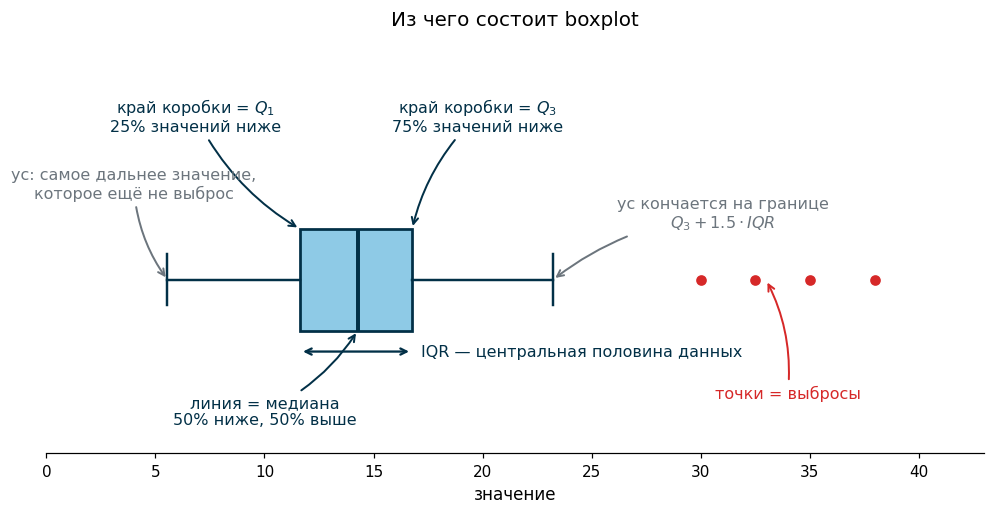

- **коробка** — от `Q1` до `Q3`, внутри неё лежит **центральная половина** данных;
- **линия внутри коробки** — **медиана**;
- **усы** — тянутся до самого дальнего значения, которое ещё **не** выброс, то есть
  укладывается в границы `1.5 · IQR`;
- **точки за усами** — те самые **выбросы** по правилу IQR.

То есть boxplot — это правило `1.5 · IQR` из части 2, нарисованное картинкой. Построим его для
времени просмотра по платформам:

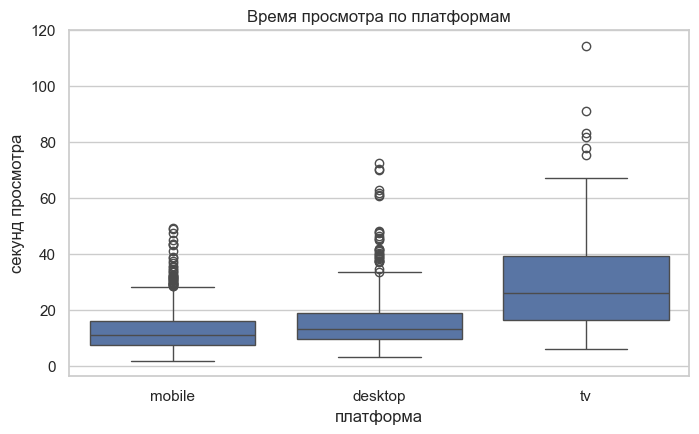

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=ads, x='platform', y='watch_time', order=['mobile', 'desktop', 'tv'], ax=ax)
ax.set_title('Время просмотра по платформам')
ax.set_xlabel('платформа'); ax.set_ylabel('секунд просмотра');

**Вывод:** коробка `tv` расположена **выше** остальных и медиана в ней заметно больше:
с телевизора ролик смотрят дольше всего, с телефона — меньше всего. У `mobile` коробка узкая
(просмотры однородно короткие), у `tv` — широкая. Точки над усами есть везде — это правый хвост
скошенного распределения.

Сверим картинку с числами: боксплот обещает, что линия в коробке — медиана, а её края — квартили.

In [11]:
ads.groupby('platform')['watch_time'].quantile([0.25, 0.5, 0.75]).unstack().round(1)

,0.25,0.50,0.75
platform,,,
desktop,9.6,13.4,19.2
mobile,7.8,11.3,16.1
tv,16.4,26.0,39.5


**Вывод:** числа совпадают с тем, что видно на графике: у `tv` медиана **26 с**, у `mobile` —
**11.3 с**, а края коробок — это ровно строки `0.25` и `0.75`. Boxplot ничего не выдумывает,
он рисует квартили.

> **Подумайте:** boxplot показывает медиану и квартили — но что он **не** покажет? Что
> произойдёт с картинкой, если внутри группы данные разделятся на **две** плотные подгруппы?

### 3.2. Слепое пятно boxplot

Соберём искусственный пример: одна выборка — обычный «колокол», вторая — **два пика** (скажем,
две разные аудитории). Подберём их так, чтобы медиана и квартили совпали, и сравним боксплоты.

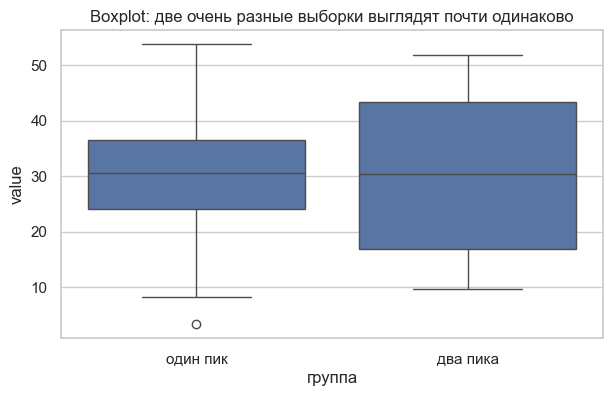

In [12]:
rng = np.random.default_rng(15)

one_peak = rng.normal(30, 9, 600)                                    # один пик
two_peaks = np.concatenate([rng.normal(17, 3, 300),                  # два пика
                            rng.normal(43, 3, 300)])

demo = pd.DataFrame({'value': np.concatenate([one_peak, two_peaks]),
                     'группа': ['один пик'] * 600 + ['два пика'] * 600})

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=demo, x='группа', y='value', ax=ax)
ax.set_title('Boxplot: две очень разные выборки выглядят почти одинаково');

**Вывод:** боксплоты почти **близнецы** — медианы и коробки совпадают. Но данные внутри
устроены совершенно по-разному, и boxplot этого не видит: он знает только пять чисел и ничего
не знает о **форме**.

### 3.3. Violin plot

**Violin plot** («скрипичный график») решает ровно эту проблему: он рисует ту же коробку, но
дополняет её **KDE-кривой плотности** (занятие 11), отражённой симметрично влево и вправо.
Шире «скрипка» — больше наблюдений на этом уровне.

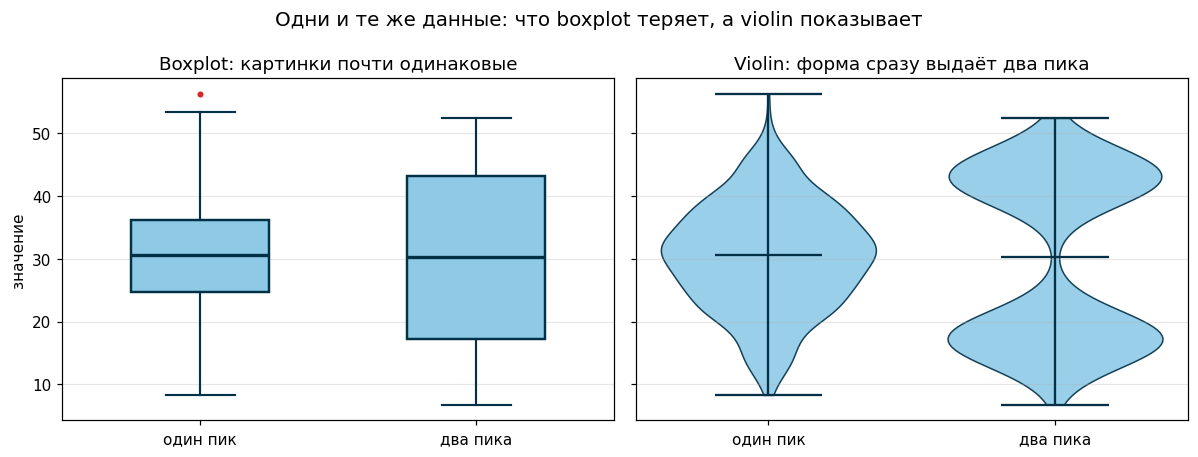

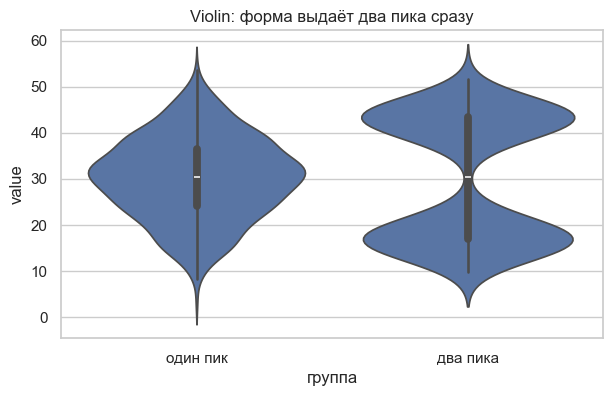

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.violinplot(data=demo, x='группа', y='value', ax=ax)
ax.set_title('Violin: форма выдаёт два пика сразу');

**Вывод:** теперь разница очевидна: слева «скрипка» с **одной** широкой серединой, справа —
с **двумя** утолщениями и перетяжкой посередине. Внутри violin по-прежнему видна белая точка
(медиана) и тёмная коробка (квартили) — вся информация boxplot сохранена, к ней добавлена форма.

> **А если** нам нужно сравнить время просмотра **двух креативов** — попробуйте описать нужный
> вызов `violinplot` по аналогии с примером выше.

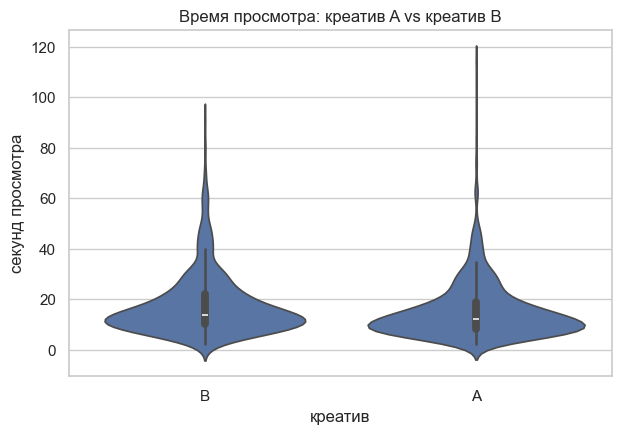

In [14]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.violinplot(data=ads, x='creative', y='watch_time', ax=ax)
ax.set_title('Время просмотра: креатив A vs креатив B')
ax.set_xlabel('креатив'); ax.set_ylabel('секунд просмотра');

**Вывод:** обе «скрипки» скошены вверх (длинный правый хвост), формы очень похожи, но
утолщение у **B** сидит чуть выше. Разница крошечная — **глазами** её не подтвердить. Именно
здесь заканчивается визуализация и начинается **проверка гипотез**.

| График | Что показывает | Когда выбрать |
|---|---|---|
| `sns.boxplot` | медиана, квартили, усы, выбросы | сравнить много групп, найти выбросы |
| `sns.violinplot` | то же + форму распределения | подозреваем несколько пиков или хитрую форму |

---
## Часть 4. Проверка гипотез: зачем она вообще нужна

### 4.1. Задача, ради которой всё затевалось

Отвлечёмся от статистики и посмотрим на ситуацию глазами **заказчика**. У него есть бюджет, и
ему надо решить **один** вопрос:

> Мы открутили оба ролика. У `B` время просмотра оказалось больше, чем у `A`.
> **Заливать весь бюджет в `B` — или нам просто повезло на этой выборке?**

Цена ошибки настоящая: если разница случайная, компания перельёт миллионы в ролик, который
ничем не лучше. Значит, нужен способ отличить **настоящий эффект** от **случайной ряби** в
данных. Этим и занимается проверка гипотез — больше ничем.

### 4.2. Разница бывает и там, где эффекта заведомо нет

Вот главная мысль всего урока, и её проще увидеть, чем объяснить.

Возьмём **только креатив `A`**. Один ролик, одна аудитория — никаких двух вариантов. Разделим
этих людей случайно **пополам** и сравним среднее время просмотра в двух половинках. Эффекта
здесь быть **не может** физически: обе половины смотрели один и тот же ролик.

Вопрос: получится ли разница ровно нулевой?


In [15]:
rng = np.random.default_rng(4)

a_only = ads[ads['creative'] == 'A']['watch_time'].values
shuffled = rng.permutation(a_only)          # случайно перемешали людей
half1, half2 = shuffled[:len(a_only) // 2], shuffled[len(a_only) // 2:]

print('половина 1: среднее =', round(half1.mean(), 2))
print('половина 2: среднее =', round(half2.mean(), 2))
print('разница на пустом месте:', round(half1.mean() - half2.mean(), 2), 'секунды')

половина 1: среднее = 16.0
половина 2: среднее = 14.88
разница на пустом месте: 1.12 секунды


**Вопрос:** мы сравнили креатив `A` сам с собой, эффекта здесь быть не может — почему тогда
разница не равна нулю? И что бы получилось, будь в каждой половине не по 380 человек, а по 5?

Отсюда следует главный вопрос анализа: наша разница между `A` и `B` — она **крупнее**, чем
такой вот шум, или ровно такая же?

### 4.3. Измеряем шум: как вообще выглядит «просто повезло»

Один запуск ничего не доказывает. Повторим фокус **1000 раз**: каждый раз перемешиваем людей
`A` случайно и записываем разницу между половинами. Получим полную картину того, **какие
разницы бывают, когда никакого эффекта нет**.

In [16]:
noise = []
for _ in range(1000):
    sh = rng.permutation(a_only)
    h1, h2 = sh[:len(a_only) // 2], sh[len(a_only) // 2:]
    noise.append(h1.mean() - h2.mean())

noise = np.array(noise)
print('разницы «на пустом месте» колеблются от', round(noise.min(), 1),
      'до', round(noise.max(), 1), 'секунд')
print('в 95% случаев шум не превышает', round(np.percentile(np.abs(noise), 95), 2), 'секунды')

разницы «на пустом месте» колеблются от -3.3 до 2.5 секунд
в 95% случаев шум не превышает 1.59 секунды


**Вывод:** случайная разница почти всегда укладывается в **±1.6 секунды**. Это и есть
«нормальный уровень вранья» наших данных. Теперь у нас есть **линейка**, которой можно померить реальную
разницу между креативами.

Нарисуем: серая гистограмма — тысяча разниц, полученных **без всякого эффекта**; красная линия —
разница, которую мы реально наблюдали между `A` и `B`.

реальная разница B − A: 2.34 секунды
случайный шум давал такую разницу в 3 случаях из 1000


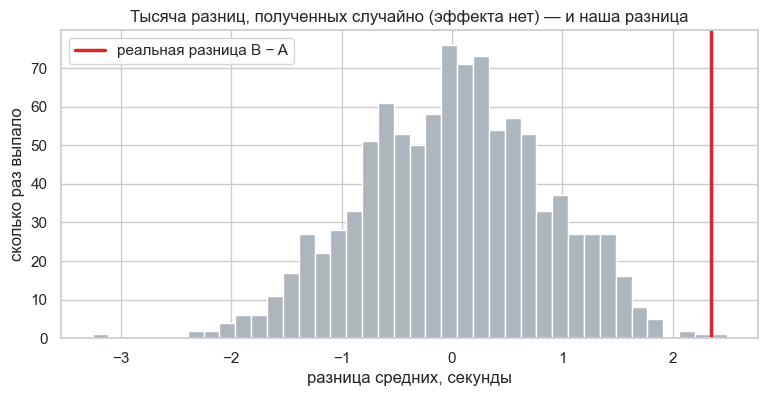

In [17]:
real_diff = (ads[ads['creative'] == 'B']['watch_time'].mean()
             - ads[ads['creative'] == 'A']['watch_time'].mean())

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(noise, bins=40, color='#adb5bd', edgecolor='white')
ax.axvline(real_diff, color='#d62828', lw=2.5, label='реальная разница B − A')
ax.set_title('Тысяча разниц, полученных случайно (эффекта нет) — и наша разница')
ax.set_xlabel('разница средних, секунды'); ax.set_ylabel('сколько раз выпало')
ax.legend()

print('реальная разница B − A:', round(real_diff, 2), 'секунды')
print('случайный шум давал такую разницу в',
      (np.abs(noise) >= abs(real_diff)).sum(), 'случаях из 1000')

**Вывод:** красная линия (**2.34 секунды**) стоит на самом краю серого холма: случайность
смогла выдать такую разницу лишь **3 раза из 1000**. То есть шанс, что нам просто повезло, —
примерно **3 на 1000, или 0.003**.

Это число и есть ответ заказчику. Оно настолько мало, что «нам показалось» — плохое объяснение;
разумнее признать, что креатив `B` **правда** удерживает зрителя дольше.

А вот если бы красная линия попала **в середину** серого холма, вывод был бы обратный: такая
разница получается сама собой в половине случаев, доказывать нечего.

**Вы только что проверили гипотезу и посчитали p-value руками.** Всё остальное в этой теме —
только названия для того, что вы уже сделали.

### 4.4. Теперь назовём вещи своими именами

Наш «мир, где эффекта нет» (перемешанные люди) в статистике называется **нулевой гипотезой**.

- **Нулевая гипотеза H₀** — «**эффекта нет**, вся разница от случайности». Это позиция
  **скептика**, и по умолчанию мы верим ей, пока не увидим убедительных улик.
- **Альтернативная гипотеза H₁** — «**эффект есть**, группы правда разные».

```
H₀:  среднее время просмотра A  =  среднее время просмотра B   (разницы нет)
H₁:  среднее время просмотра A  ≠  среднее время просмотра B   (разница есть)
```

А доля случаев, когда шум выдавал разницу не меньше нашей (у нас — **3 из 1000**, то есть
**0.003**), называется **p-value**.

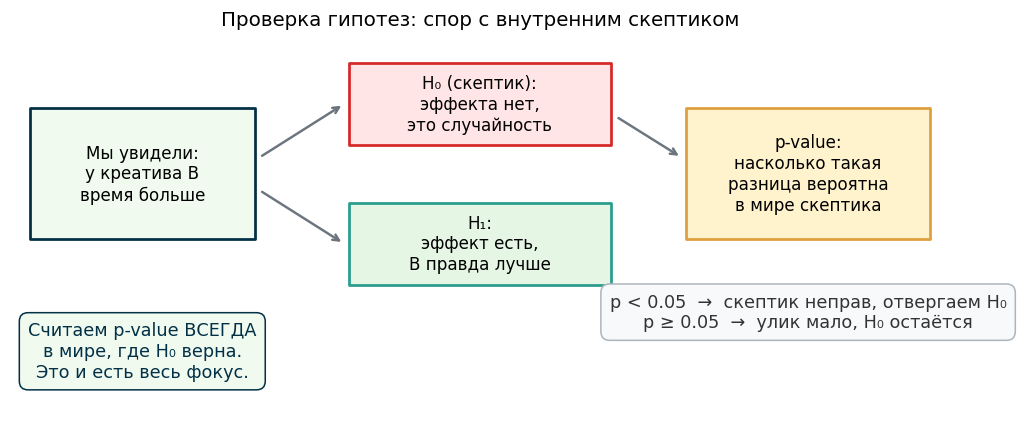

### 4.5. p-value простыми словами

**p-value** отвечает ровно на тот вопрос, который мы решали симуляцией:

> Если бы эффекта **не было** — как часто случайность выдавала бы разницу **такую же большую
> или больше**, как у нас?

- **p-value = 0.60** — такая разница возникает случайно в 60% случаев. Обычное дело, ничего
  удивительного. **H₀ устояла**, улик нет.
- **p-value = 0.002** — случайность выдала бы такое лишь дважды на тысячу попыток. Слишком
  невероятно, чтобы объяснять везением → **отвергаем H₀**, эффект признаём настоящим.

Порог «достаточно невероятного» выбирают **заранее** и называют **уровнем значимости α**.
Общепринятый стандарт — **0.05**, то есть «готовы ошибаться не чаще, чем в 1 случае из 20».

```
p-value < 0.05  →  отвергаем H₀   →  «различие статистически значимо»
p-value ≥ 0.05  →  H₀ не отвергаем →  «улик недостаточно»
```

### 4.6. Две ошибки, которые делают почти все

**Первая: «p-value — это вероятность того, что H₀ верна».** Нет. Мы считали долю **среди
случайных перемешиваний** — то есть вероятность **таких данных** в мире, где H₀ верна. Обратное
(«вероятность, что H₀ верна при таких данных») — совсем другая величина, и p-value её не даёт.

**Вторая: «H₀ не отвергли — значит, эффекта нет».** Тоже нет. Это значит только, что **улик не
хватило**. Возможно, эффект есть, но группа слишком мала, чтобы его разглядеть в шуме, — ровно
такой случай мы увидим в конце урока на платформах.

> **На практике:** тесты, которыми мы займёмся дальше, делают ровно то же самое, что наша
> симуляция, только не перебором, а **формулой** — мгновенно и без тысячи циклов. Понимать
> имеет смысл именно симуляцию: формула — лишь быстрый способ получить тот же ответ.

---
## Часть 5. Три теста

Тест — это калькулятор, который по двум выборкам считает p-value. Выбор теста зависит от того,
**что** мы сравниваем.

| Что сравниваем | Тест | Функция `scipy.stats` |
|---|---|---|
| **средние** двух групп, данные ~нормальны | t-тест Стьюдента | `ttest_ind` |
| **центры** двух групп, данные скошены/есть выбросы | критерий Манна–Уитни | `mannwhitneyu` |
| **доли** (конверсия, CTR) | χ² (хи-квадрат) | `chi2_contingency` |

### 5.1. t-тест Стьюдента

**t-тест** сравнивает **средние** двух групп. Он берёт разницу средних и делит её на разброс
данных — то есть спрашивает: «велика ли разница **по меркам самого шума**?»

$$t = \frac{\bar{x}_A - \bar{x}_B}{\text{оценка разброса}}$$

Чем больше `t` по модулю, тем меньше p-value. Проверим креативы — но **на исходной**,
неочищенной таблице `df`, вместе с ботами: посмотрим, что получится.

In [18]:
a_raw = df[df['creative'] == 'A']['watch_time']
b_raw = df[df['creative'] == 'B']['watch_time']

t_stat, p_val = stats.ttest_ind(a_raw, b_raw)
print('среднее A:', round(a_raw.mean(), 1), '| среднее B:', round(b_raw.mean(), 1))
print('t =', round(t_stat, 2), '| p-value =', round(p_val, 3))

среднее A: 23.9 | среднее B: 25.6
t = -0.54 | p-value = 0.591


**Вопрос:** тест сообщает, что различие незначимо. Но t-тест делит разницу средних на оценку
разброса — а что мы знаем про разброс этих данных, чего не знает тест?

Повторим тест на очищенной таблице:

In [19]:
a = ads[ads['creative'] == 'A']['watch_time']
b = ads[ads['creative'] == 'B']['watch_time']

t_stat, p_val = stats.ttest_ind(a, b)
print('среднее A:', round(a.mean(), 1), '| среднее B:', round(b.mean(), 1))
print('t =', round(t_stat, 2), '| p-value =', round(p_val, 4))

среднее A: 15.4 | среднее B: 17.8
t = -3.9 | p-value = 0.0001


**Вывод:** p-value = **0.0001** — намного меньше 0.05, **H₀ отвергаем**: креатив `B` удерживает
зрителя дольше (**17.8 с** против **15.4 с**), и это статистически значимо. Те же люди, тот же
вопрос, но **32 бота** переворачивали ответ на противоположный. Вот зачем первые две части урока
были про выбросы.

> **На практике:** t-тест предполагает, что данные примерно нормальны, а его чувствительность
> к выбросам — прямое следствие: он считает **среднее** и **std**, а обе меры неустойчивы.

### 5.2. Критерий Манна–Уитни

`watch_time` скошен вправо — для t-теста это не идеальные условия. **Критерий Манна–Уитни** не
использует ни средние, ни стандартные отклонения. Он **ранжирует** все наблюдения (самое
короткое — ранг 1, следующее — ранг 2, …) и проверяет, не собрались ли ранги одной группы
систематически выше.

Раз работа идёт с **рангами**, а не со значениями, гигантский просмотр бота получает всего лишь
«последнее место» — и на результат почти не влияет. Проверим это: запустим тест на **грязных**
данных, где t-тест провалился.

In [20]:
u_stat, p_val = stats.mannwhitneyu(a_raw, b_raw)   # на данных С ботами
print('медиана A:', a_raw.median(), '| медиана B:', b_raw.median())
print('U =', u_stat, '| p-value =', round(p_val, 5))

медиана A: 12.6 | медиана B: 14.2
U = 276065.0 | p-value = 0.0


**Вопрос:** на тех же данных с ботами t-тест дал 0.59, а Манн–Уитни — почти ноль. Что
происходит с просмотром бота в 595 секунд, когда тест заменяет значения на **ранги**?

| | t-тест | Манна–Уитни |
|---|---|---|
| Что сравнивает | средние | ранги (сдвиг распределения) |
| Требует нормальности | да | **нет** |
| Устойчив к выбросам | нет | **да** |
| Когда брать | данные ~нормальны, выбросов нет | скос, выбросы, малые выборки |

> **А если** в столбце `watch_time` окажутся пропуски — что вернёт `ttest_ind`? Прикиньте
> ответ, опираясь на то, как ведёт себя арифметика с `NaN`, и проверим.

In [21]:
a_nan = a.copy()
a_nan.iloc[:5] = np.nan   # добавим пять пропусков

print('с пропусками:      p-value =', stats.ttest_ind(a_nan, b).pvalue)
print('nan_policy=omit:   p-value =', round(stats.ttest_ind(a_nan, b, nan_policy='omit').pvalue, 4))

с пропусками:      p-value = nan
nan_policy=omit:   p-value = 0.0001


**Вывод:** по умолчанию тест возвращает **`nan`** — один пропуск отравляет всё среднее, и
результат бессмысленный. Нужно либо чистить данные заранее (`.dropna()`), либо явно передать
`nan_policy='omit'`. Тихой ошибки не будет, но `nan` в отчёте легко не заметить.

### 5.3. χ² — критерий для долей

Время просмотра — не единственная метрика. Заказчику важнее **клики**. `clicked` — это не число,
а **да/нет**, поэтому средние тут ни при чём: сравниваем **доли** (CTR — доля кликнувших).

Для долей есть **критерий χ²** (хи-квадрат). Он работает с **таблицей сопряжённости** — сколько
объектов попало в каждую комбинацию категорий.

In [22]:
table = pd.crosstab(ads['creative'], ads['clicked'])
table.columns = ['не кликнул', 'кликнул']
print(table)
print()
print('CTR:', (table['кликнул'] / table.sum(axis=1)).round(3).to_dict())

          не кликнул  кликнул
creative                     
A                691       72
B                694      111

CTR: {'A': 0.094, 'B': 0.138}


**Вывод:** у креатива `A` кликают **9.4%** зрителей, у `B` — **13.8%**. Разница в полтора раза
выглядит внушительно, но в абсолютных числах это **72** клика против **111** — на таких числах
вполне могло и повезти. Нужен тест.

Идея χ² такая: посчитаем, сколько кликов **ожидалось бы**, будь креативы одинаковыми
(тогда CTR у обоих равнялся бы общему CTR), и сравним с тем, что **наблюдали**:

$$\chi^2 = \sum \frac{(\text{наблюдалось} - \text{ожидалось})^2}{\text{ожидалось}}$$

Чем сильнее факт разошёлся с ожиданием, тем больше χ² и тем меньше p-value.

```
H₀:  CTR креатива A  =  CTR креатива B   (креатив не влияет на клик)
H₁:  CTR креатива A  ≠  CTR креатива B
```

In [23]:
chi2, p_val, dof, expected = stats.chi2_contingency(table)

print('ожидалось при H₀ (креативы одинаковы):')
print(pd.DataFrame(expected, index=table.index, columns=table.columns).round(1))
print()
print('chi2 =', round(chi2, 2), '| p-value =', round(p_val, 4))

ожидалось при H₀ (креативы одинаковы):
          не кликнул  кликнул
creative                     
A              674.0     89.0
B              711.0     94.0

chi2 = 6.78 | p-value = 0.0092


**Вывод:** при верной H₀ ожидалось бы около **89** кликов у `A` и **94** у `B` (доли равны,
разница только из-за размера групп), а наблюдали **72** и **111**. p-value = **0.009** < 0.05 →
**H₀ отвергаем**: креатив `B` даёт статистически значимо более высокий CTR.

> **На практике:** χ² — рабочая лошадка **A/B-тестов**. Любое сравнение конверсий («купил /
> не купил», «подписался / нет», «кликнул / нет») в двух вариантах интерфейса решается именно им.

> **Попробуйте сами:** мы сравнивали CTR по креативу. Как проверить, зависит ли клик от
> **платформы**? Что нужно поменять всего в одной строке кода выше?

In [24]:
table_platform = pd.crosstab(ads['platform'], ads['clicked'])
chi2, p_val, dof, expected = stats.chi2_contingency(table_platform)

print('CTR по платформам:',
      (table_platform[1] / table_platform.sum(axis=1)).round(3).to_dict())
print('chi2 =', round(chi2, 2), '| p-value =', round(p_val, 4))

CTR по платформам: {'desktop': 0.119, 'mobile': 0.123, 'tv': 0.089}
chi2 = 2.12 | p-value = 0.3466


**Вопрос:** CTR на `tv` — 8.9%, на `mobile` — 12.3%, разница видна глазами. Но p-value = **0.35**,
и H₀ мы не отвергаем. Означает ли это, что платформа на клик **не влияет**? Сколько зрителей
`tv` вообще было в данных?

### 5.4. Итоговый ответ заказчику

Соберём всё, что выяснили про креативы, в один вывод.

In [25]:
print('Креатив B против креатива A (после удаления 32 ботов):')
print('  время просмотра: {:.1f} с против {:.1f} с, p = {:.4f}'.format(
    b.mean(), a.mean(), stats.ttest_ind(a, b).pvalue))
print('  CTR:             {:.1%} против {:.1%}, p = {:.4f}'.format(
    ads[ads['creative'] == 'B']['clicked'].mean(),
    ads[ads['creative'] == 'A']['clicked'].mean(),
    stats.chi2_contingency(pd.crosstab(ads['creative'], ads['clicked']))[1]))

Креатив B против креатива A (после удаления 32 ботов):
  время просмотра: 17.8 с против 15.4 с, p = 0.0001
  CTR:             13.8% против 9.4%, p = 0.0092


**Вывод:** по **обеим** метрикам креатив `B` выигрывает, и оба p-value меньше 0.05.
Рекомендация заказчику: **запускать `B`** — и это утверждение теперь подкреплено не «на глаз»,
а проверкой гипотез.

---
## Итог занятия

Сегодня научились:
- различать **природу выбросов** — ошибка, артефакт, редкое настоящее значение — и понимать,
  что удалять их не глядя нельзя;
- искать аномалии двумя правилами: **IQR** (`Q1 − 1.5·IQR`, `Q3 + 1.5·IQR`, устойчиво) и
  **Z-score** (`|z| > 3`, само страдает от выбросов);
- читать **boxplot** по геометрии — коробка `Q1…Q3`, линия-медиана, усы в пределах `1.5·IQR`,
  точки-выбросы — и знать его слепое пятно: он не видит **форму**;
- дополнять его **violin plot**, который показывает плотность и выдаёт два пика;
- формулировать **H₀** («эффекта нет») и **H₁**, понимать **p-value** как «вероятность таких
  данных, если эффекта нет», и сравнивать его с **α = 0.05**;
- выбирать тест: **`ttest_ind`** для средних, **`mannwhitneyu`** для скошенных данных и
  выбросов, **`chi2_contingency`** для долей и конверсий.

**Главная мысль:** проверка гипотез начинается **раньше** самого теста. Один и тот же t-тест на
наших данных сказал «разницы нет» (p = 0.59) до чистки и «разница есть» (p = 0.0001) после —
потому что 32 бота из 1600 раздули разброс. Сначала смотри на разброс и аномалии, потом выбирай
тест под **природу данных**, и только потом читай p-value.